Import and Load the data

In [1]:
import pandas as pd

content_df = pd.read_csv("../data/raw/content_based_data.csv")
collab_df = pd.read_csv("../data/raw/collaborative_filtering_data.csv")

Data Preprocessing

In [2]:
print(content_df.head())

     Artist                                          Track  \
0  Gorillaz                                 Feel Good Inc.   
1  Gorillaz                                Rhinestone Eyes   
2  Gorillaz  New Gold (feat. Tame Impala and Bootie Brown)   
3  Gorillaz                             On Melancholy Hill   
4  Gorillaz                                 Clint Eastwood   

                                           Album Genre  Danceability  Energy  \
0                                     Demon Days   Alt         0.818   0.705   
1                                  Plastic Beach   Alt         0.676   0.703   
2  New Gold (feat. Tame Impala and Bootie Brown)   Alt         0.695   0.923   
3                                  Plastic Beach   Alt         0.689   0.739   
4                                       Gorillaz   Alt         0.663   0.694   

   Loudness  Speechiness  Acousticness  Instrumentalness  Liveness  Valence  \
0    -6.679       0.1770      0.008360          0.002330    0.6130 

In [3]:
print(collab_df.head())

         User_ID    Artist  Play_Count User_Age_Group User_Gender User_Profile
0  USRC6D5E02AC5  Gorillaz          28          25-34        Male     Rock/Alt
1  USR72B40D92CC  Gorillaz          17          35-49      Female     Rock/Alt
2  USRF4DD23AE07  Gorillaz          17          35-49      Female     Rock/Alt
3  USR1EEFEED9E5  Gorillaz          17          35-49      Female     Rock/Alt
4  USRF46E2FF3C9  Gorillaz          28          25-34        Male     Rock/Alt


In [4]:
print(content_df.shape)
print(content_df.isnull().sum())

(20594, 14)
Artist              0
Track               0
Album               0
Genre               0
Danceability        0
Energy              0
Loudness            0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
Popularity          0
dtype: int64


In [5]:
print(collab_df.shape)
print(collab_df.isnull().sum())

(241597, 6)
User_ID           0
Artist            0
Play_Count        0
User_Age_Group    0
User_Gender       0
User_Profile      0
dtype: int64


In [6]:
content_df = content_df.dropna()
collab_df = collab_df.dropna()

DISTRIBUTION OF MUSIC FEATURES

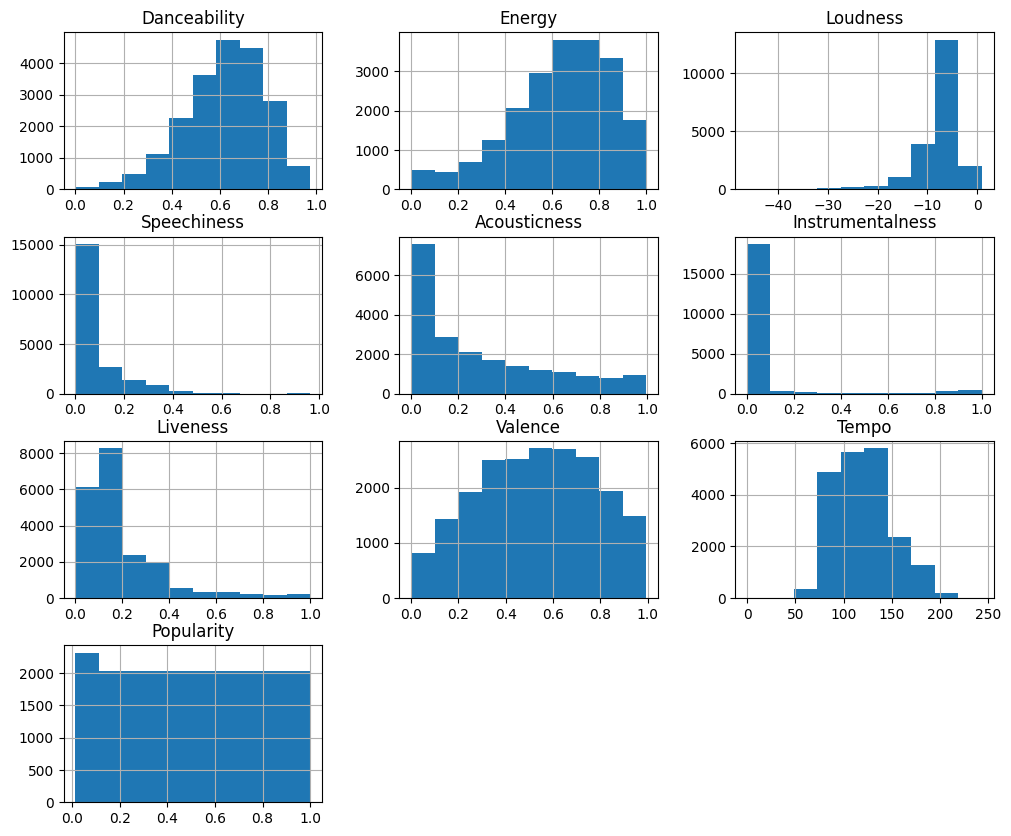

In [7]:
import matplotlib.pyplot as plt

features = [
'Danceability','Energy','Loudness',
'Speechiness','Acousticness',
'Instrumentalness','Liveness',
'Valence','Tempo','Popularity'
]

content_df[features].hist(figsize=(12,10))
plt.show()

CORRELATION HEATMAP

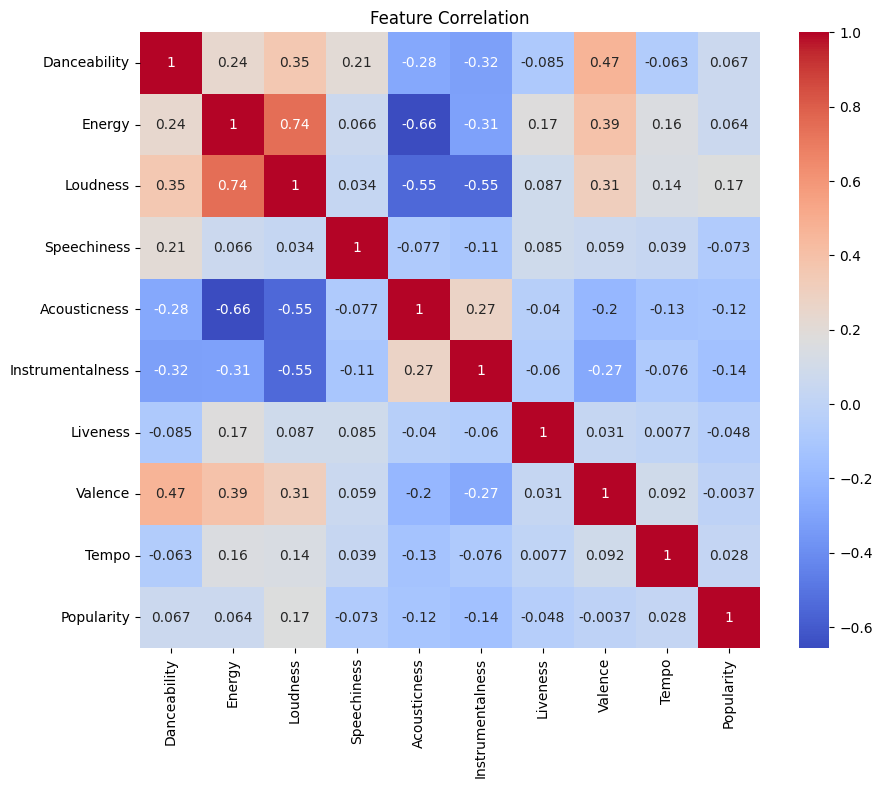

In [9]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(

content_df[features].corr(),

annot=True,

cmap='coolwarm'

)

plt.title("Feature Correlation")

plt.show()

GENRE DISTRIBUTION

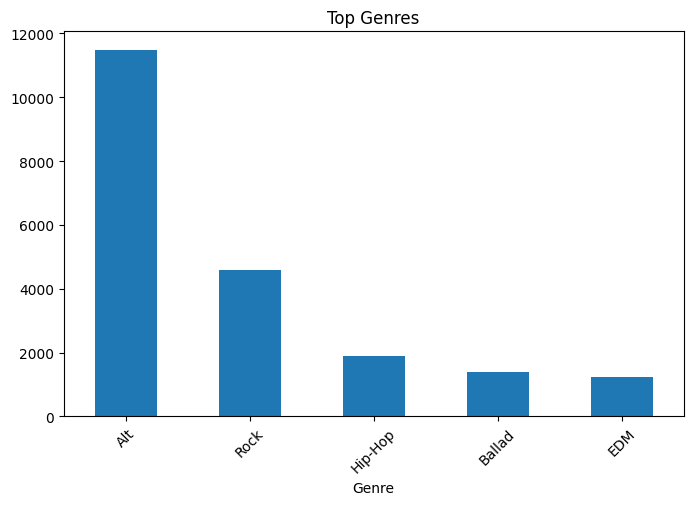

In [10]:
plt.figure(figsize=(8,5))

content_df['Genre'].value_counts().head(10).plot(kind='bar')

plt.title("Top Genres")

plt.xticks(rotation=45)

plt.show()

POPULAR ARTISTS

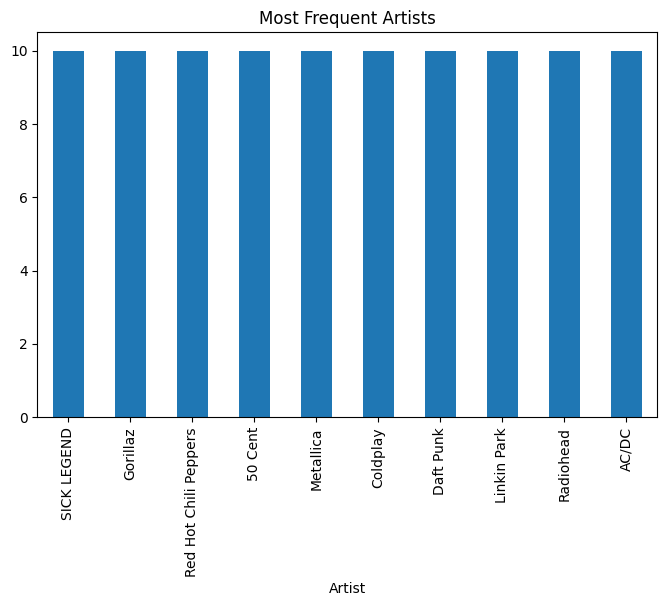

In [11]:
content_df['Artist'].value_counts().head(10).plot(

kind='bar',

figsize=(8,5)

)

plt.title("Most Frequent Artists")

plt.show()

USER BEHAVIOUR ANALYSIS (COLLABORATIVE DATA)

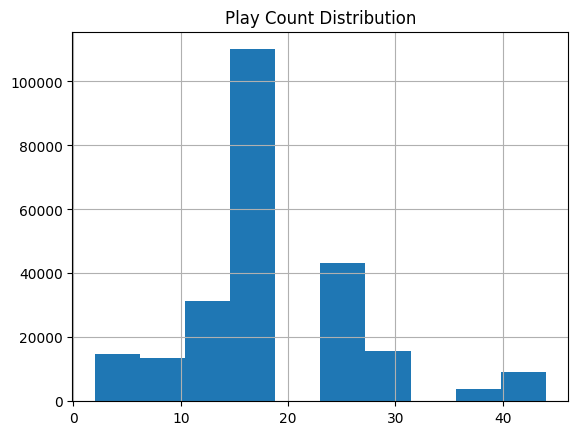

In [12]:
collab_df['Play_Count'].hist()

plt.title("Play Count Distribution")

plt.show()

MOST PLAYED ARTISTS

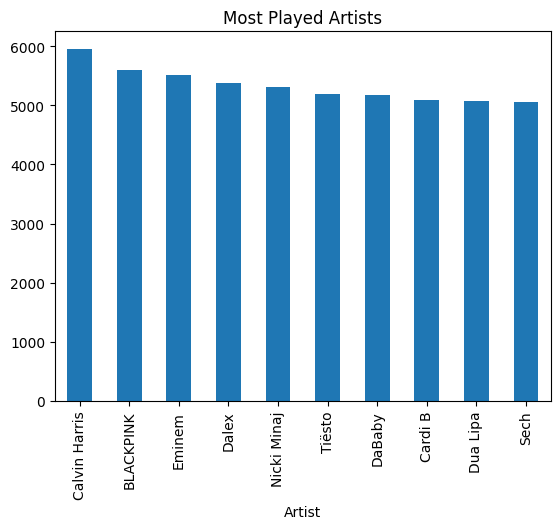

In [13]:
collab_df.groupby('Artist')['Play_Count'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Most Played Artists")

plt.show()